In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("../data/hotel_bookings_cleaned.csv")

print("Dataset shape:", df.shape)

# Target variable
y = df["adr"]

# Remove target and columns that are outcomes/post-booking information
X = df.drop(columns=[
    "adr",
    "reservation_status",
    "reservation_status_date",
    "is_canceled"
])

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Preprocessing for linear models
# One-hot for categories, scaling for numbers (fitted inside the pipeline
# on training data only, so no leakage from the test set)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat",
         OneHotEncoder(handle_unknown="ignore"),
         categorical_cols),

        ("num",
         StandardScaler(),
         numerical_cols)
    ]
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Target: ADR")

Dataset shape: (87394, 37)
Training data: (69915, 33)
Testing data: (17479, 33)
Target: ADR


C:\Users\manin\AppData\Local\Temp\ipykernel_33568\1258780800.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


Linear Regression Results
-------------------------
MAE : 22.85
RMSE: 31.25
R²  : 0.6473

Total features after preprocessing: 252

Top 15 Coefficients (by absolute value):
                               Feature  Coefficient
190  cat__market_segment_Complementary   -78.961857
6      cat__arrival_date_month_January   -73.692337
5     cat__arrival_date_month_February   -63.015029
3       cat__arrival_date_month_August    53.405176
23                    cat__country_AND    50.104458
9        cat__arrival_date_month_March   -48.161230
208          cat__reserved_room_type_H    47.131773
150                   cat__country_PYF    44.704417
13   cat__arrival_date_month_September    41.654932
202          cat__reserved_room_type_B   -41.420001
21                    cat__country_AIA    38.955752
57                    cat__country_CYM   -37.820633
61                    cat__country_DMA   -37.251810
83                    cat__country_GTM   -36.858096
17                        cat__meal_SC   -36.445

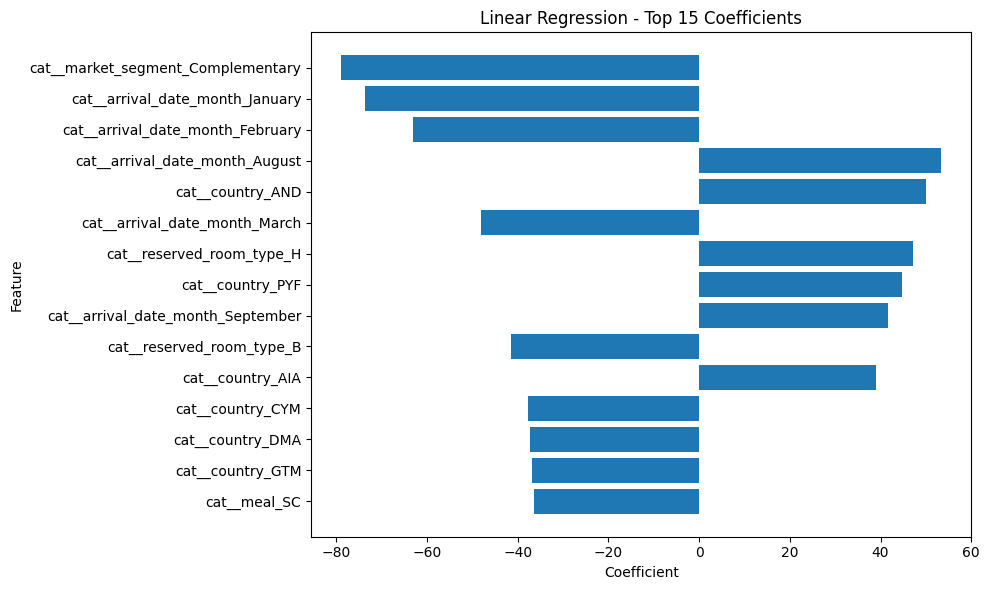

In [2]:
from sklearn.linear_model import LinearRegression

# Linear Regression pipeline (baseline)
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train
lr_pipeline.fit(X_train, y_train)

# Prediction
lr_pred = lr_pipeline.predict(X_test)

# Evaluation
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(lr_mae, 2))
print("RMSE:", round(lr_rmse, 2))
print("R\u00b2  :", round(lr_r2, 4))

# Coefficients
feature_names = lr_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

lr_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr_pipeline.named_steps["model"].coef_
})

lr_coef_df["Abs_Coefficient"] = lr_coef_df["Coefficient"].abs()

lr_coef_df = lr_coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

print("\nTotal features after preprocessing:", len(feature_names))
print("\nTop 15 Coefficients (by absolute value):")
print(lr_coef_df[["Feature", "Coefficient"]].head(15))

top_coef = lr_coef_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_coef["Feature"][::-1],
    top_coef["Coefficient"][::-1]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Linear Regression - Top 15 Coefficients")

plt.tight_layout()
plt.show()

Best alpha: {'model__alpha': 1.0}

Ridge Regression Results
------------------------
MAE : 22.85
RMSE: 31.25
R²  : 0.6473


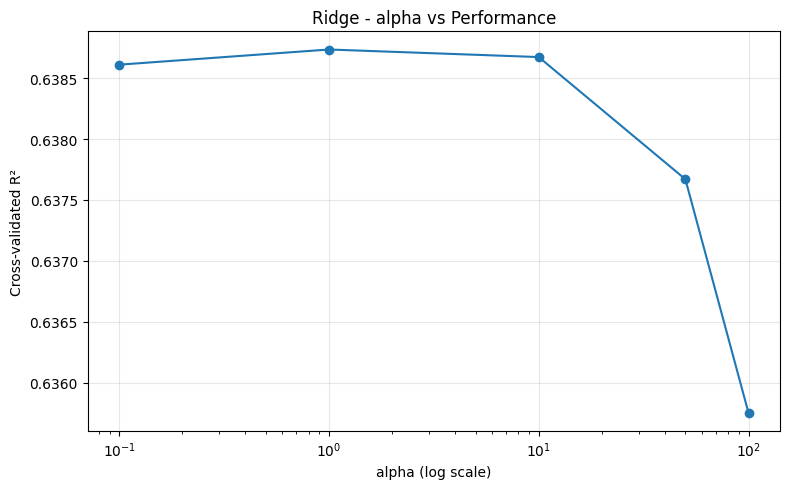

In [3]:
from sklearn.linear_model import Ridge

# Ridge pipeline (L2 regularisation)
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(random_state=42))
])

# Tune alpha
ridge_params = {
    "model__alpha": [0.1, 1.0, 10.0, 50.0, 100.0]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

# Train
ridge_grid.fit(X_train, y_train)

# Best parameter
print("Best alpha:", ridge_grid.best_params_)

# Prediction
ridge_pred = ridge_grid.predict(X_test)

# Evaluation
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("\nRidge Regression Results")
print("------------------------")
print("MAE :", round(ridge_mae, 2))
print("RMSE:", round(ridge_rmse, 2))
print("R\u00b2  :", round(ridge_r2, 4))

# Alpha vs performance
ridge_alphas = ridge_params["model__alpha"]
ridge_cv_scores = ridge_grid.cv_results_["mean_test_score"]

plt.figure(figsize=(8, 5))

plt.plot(
    ridge_alphas,
    ridge_cv_scores,
    marker="o"
)

plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("Cross-validated R\u00b2")
plt.title("Ridge - alpha vs Performance")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\manin\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:675: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.855e+06, tolerance: 1.881e+04
  model = cd_fast.sparse_enet_coordinate_descent(


Best alpha: {'model__alpha': 0.001}

Lasso Regression Results
------------------------
MAE : 22.85
RMSE: 31.25
R²  : 0.6472

Feature Sparsity
----------------
Total features     : 252
Zero coefficients  : 99
Non-zero features  : 153
Sparsity (%)       : 39.29

Top 15 Surviving Features:
                               Feature  Coefficient
190  cat__market_segment_Complementary   -85.830323
6      cat__arrival_date_month_January   -54.884915
5     cat__arrival_date_month_February   -48.336653
208          cat__reserved_room_type_H    46.789208
220          cat__assigned_room_type_K   -45.538138
210          cat__reserved_room_type_P   -45.365136
219          cat__assigned_room_type_I   -44.803569
3       cat__arrival_date_month_August    44.011556
202          cat__reserved_room_type_B   -40.066746
9        cat__arrival_date_month_March   -37.282405
15                        cat__meal_FB    36.055218
23                    cat__country_AND    36.022177
17                        cat__meal_

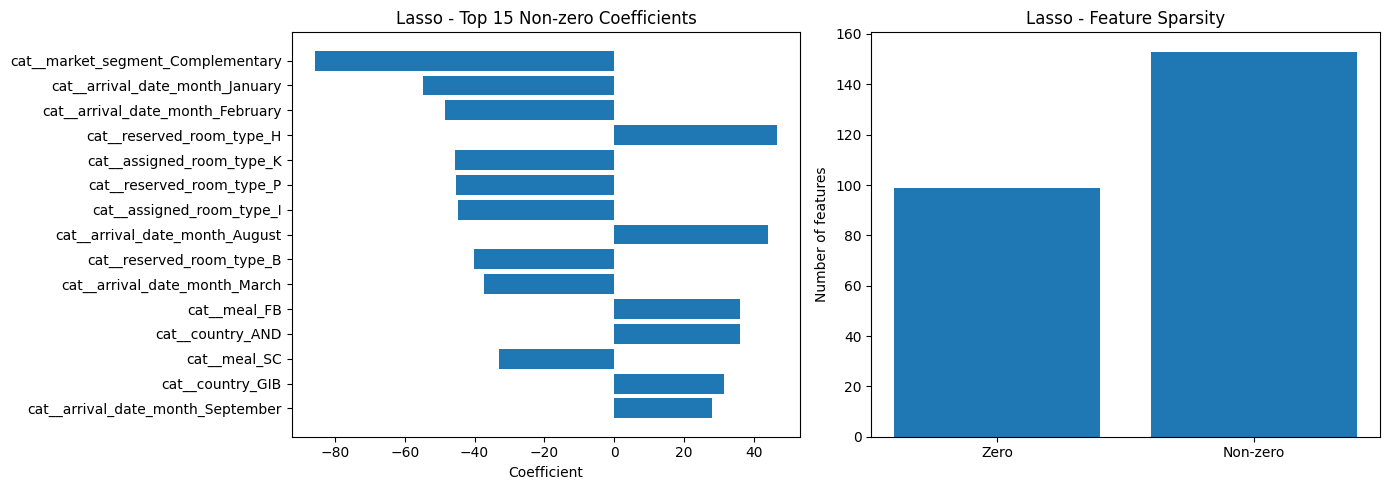

In [4]:
from sklearn.linear_model import Lasso

# Lasso pipeline (L1 regularisation)
lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=2000, random_state=42))
])

# Tune alpha
lasso_params = {
    "model__alpha": [0.001, 0.01, 0.1, 1.0]
}

lasso_grid = GridSearchCV(
    lasso_pipeline,
    lasso_params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

# Train
lasso_grid.fit(X_train, y_train)

# Best parameter
print("Best alpha:", lasso_grid.best_params_)

# Prediction
lasso_pred = lasso_grid.predict(X_test)

# Evaluation
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_r2 = r2_score(y_test, lasso_pred)

print("\nLasso Regression Results")
print("------------------------")
print("MAE :", round(lasso_mae, 2))
print("RMSE:", round(lasso_rmse, 2))
print("R\u00b2  :", round(lasso_r2, 4))

# Feature sparsity
lasso_model = lasso_grid.best_estimator_.named_steps["model"]

lasso_coef = lasso_model.coef_
n_total = len(lasso_coef)
n_zero = int(np.sum(lasso_coef == 0))

print("\nFeature Sparsity")
print("----------------")
print("Total features     :", n_total)
print("Zero coefficients  :", n_zero)
print("Non-zero features  :", n_total - n_zero)
print("Sparsity (%)       :", round(100 * n_zero / n_total, 2))

lasso_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lasso_coef
})

lasso_nonzero = lasso_coef_df[lasso_coef_df["Coefficient"] != 0].copy()

lasso_nonzero["Abs_Coefficient"] = lasso_nonzero["Coefficient"].abs()

lasso_nonzero = lasso_nonzero.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

print("\nTop 15 Surviving Features:")
print(lasso_nonzero[["Feature", "Coefficient"]].head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_lasso = lasso_nonzero.head(15)

axes[0].barh(
    top_lasso["Feature"][::-1],
    top_lasso["Coefficient"][::-1]
)

axes[0].set_xlabel("Coefficient")
axes[0].set_title("Lasso - Top 15 Non-zero Coefficients")

axes[1].bar(
    ["Zero", "Non-zero"],
    [n_zero, n_total - n_zero]
)

axes[1].set_ylabel("Number of features")
axes[1].set_title("Lasso - Feature Sparsity")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import ElasticNet

# ElasticNet pipeline (L1 + L2)
enet_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ElasticNet(max_iter=2000, random_state=42))
])

# Tune l1_ratio (with a small alpha grid)
enet_params = {
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
    "model__alpha": [0.01, 0.1]
}

enet_grid = GridSearchCV(
    enet_pipeline,
    enet_params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

# Train
enet_grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(enet_grid.best_params_)

# Prediction
enet_pred = enet_grid.predict(X_test)

# Evaluation
enet_mae = mean_absolute_error(y_test, enet_pred)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))
enet_r2 = r2_score(y_test, enet_pred)

print("\nElasticNet Regression Results")
print("-----------------------------")
print("MAE :", round(enet_mae, 2))
print("RMSE:", round(enet_rmse, 2))
print("R\u00b2  :", round(enet_r2, 4))

# Sparsity of the selected model
enet_coef = enet_grid.best_estimator_.named_steps["model"].coef_

print("\nZero coefficients:",
      int(np.sum(enet_coef == 0)), "/", len(enet_coef))

# l1_ratio vs performance
enet_cv = pd.DataFrame(enet_grid.cv_results_)

plt.figure(figsize=(8, 5))

for alpha in enet_params["model__alpha"]:
    subset = enet_cv[enet_cv["param_model__alpha"] == alpha]

    subset = subset.sort_values("param_model__l1_ratio")

    plt.plot(
        subset["param_model__l1_ratio"],
        subset["mean_test_score"],
        marker="o",
        label="alpha = " + str(alpha)
    )

plt.xlabel("l1_ratio")
plt.ylabel("Cross-validated R\u00b2")
plt.title("ElasticNet - l1_ratio vs Performance")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Degree 1 done
Degree 2 done

Polynomial Degree Comparison
----------------------------
   Degree  Features      MAE     RMSE      R2
0       1       252  22.8510  31.2493  0.6473
1       2       528  22.0898  30.3698  0.6668

Selected degree: 2

Polynomial Regression Results
-----------------------------
MAE : 22.09
RMSE: 30.37
R²  : 0.6668


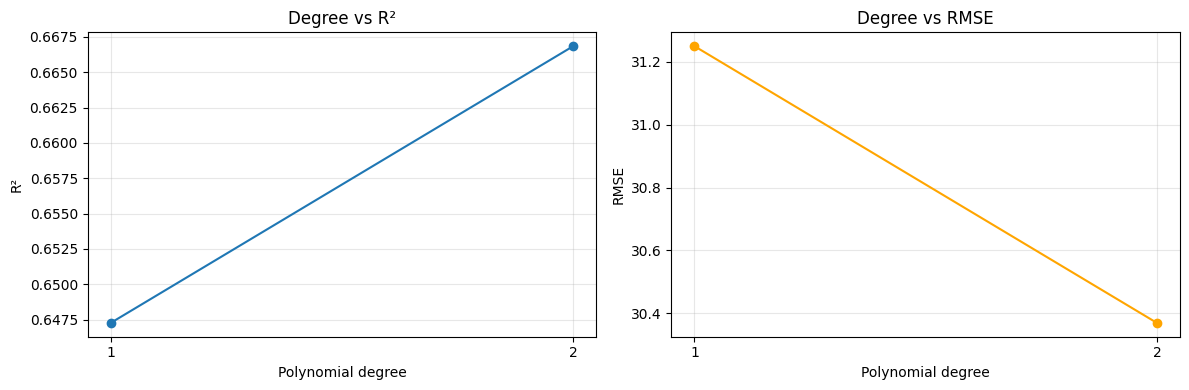

In [ ]:
# Polynomial Regression = PolynomialFeatures + Linear Regression
# Expansion is applied only to the numeric columns, the categorical columns
# are still one-hot encoded (a degree-2 expansion of ~250 one-hot columns
# would be far too large for a laptop)

poly_degrees = [1, 2]

poly_scores = []
poly_models = {}

for degree in poly_degrees:

    poly_preprocessor = ColumnTransformer([
        ("cat",
         OneHotEncoder(handle_unknown="ignore"),
         categorical_cols),

        ("num",
         Pipeline([
             ("scaler", StandardScaler()),
             ("poly", PolynomialFeatures(
                 degree=degree,
                 include_bias=False
             ))
         ]),
         numerical_cols)
    ])

    poly_pipeline = Pipeline([
        ("preprocessor", poly_preprocessor),
        ("model", LinearRegression())
    ])

    # Train
    poly_pipeline.fit(X_train, y_train)

    # Prediction
    poly_pred_d = poly_pipeline.predict(X_test)

    # Evaluation
    poly_scores.append({
        "Degree": degree,
        "Features": len(
            poly_pipeline.named_steps["preprocessor"].get_feature_names_out()
        ),
        "MAE": mean_absolute_error(y_test, poly_pred_d),
        "RMSE": np.sqrt(mean_squared_error(y_test, poly_pred_d)),
        "R2": r2_score(y_test, poly_pred_d)
    })

    poly_models[degree] = poly_pipeline

    print("Degree", degree, "done")

poly_results = pd.DataFrame(poly_scores)

print("\nPolynomial Degree Comparison")
print("----------------------------")
print(poly_results.round(4))

# Best degree
best_degree = int(
    poly_results.loc[poly_results["R2"].idxmax(), "Degree"]
)

poly_best = poly_models[best_degree]

poly_pred = poly_best.predict(X_test)

poly_mae = mean_absolute_error(y_test, poly_pred)
poly_rmse = np.sqrt(mean_squared_error(y_test, poly_pred))
poly_r2 = r2_score(y_test, poly_pred)

print("\nSelected degree:", best_degree)
print("\nPolynomial Regression Results")
print("-----------------------------")
print("MAE :", round(poly_mae, 2))
print("RMSE:", round(poly_rmse, 2))
print("R\u00b2  :", round(poly_r2, 4))

# Degree vs performance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    poly_results["Degree"],
    poly_results["R2"],
    marker="o"
)

axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("R\u00b2")
axes[0].set_title("Degree vs R\u00b2")
axes[0].set_xticks(poly_degrees)
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    poly_results["Degree"],
    poly_results["RMSE"],
    marker="o",
    color="orange"
)

axes[1].set_xlabel("Polynomial degree")
axes[1].set_ylabel("RMSE")
axes[1].set_title("Degree vs RMSE")
axes[1].set_xticks(poly_degrees)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# One row per algorithm (best configuration only)
results = pd.DataFrame({
    "Algorithm": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "ElasticNet",
        "Polynomial"
    ],

    "MAE": [
        lr_mae,
        ridge_mae,
        lasso_mae,
        enet_mae,
        poly_mae
    ],

    "RMSE": [
        lr_rmse,
        ridge_rmse,
        lasso_rmse,
        enet_rmse,
        poly_rmse
    ],

    "R2": [
        lr_r2,
        ridge_r2,
        lasso_r2,
        enet_r2,
        poly_r2
    ]
})

results["CV_R2_5fold"] = np.nan

# Selected hyperparameters (shown separately)
selected_params = pd.DataFrame({
    "Algorithm": results["Algorithm"],

    "Selected Hyperparameters": [
        "none (baseline)",
        "alpha = " + str(ridge_grid.best_params_["model__alpha"]),
        "alpha = " + str(lasso_grid.best_params_["model__alpha"]),
        "alpha = " + str(enet_grid.best_params_["model__alpha"]) +
        ", l1_ratio = " + str(enet_grid.best_params_["model__l1_ratio"]),
        "degree = " + str(best_degree)
    ]
})

print("Selected Hyperparameters")
print("------------------------")
print(selected_params)

results.round(4)

Selected Hyperparameters
------------------------
           Algorithm      Selected Hyperparameters
0  Linear Regression               none (baseline)
1              Ridge                   alpha = 1.0
2              Lasso                 alpha = 0.001
3         ElasticNet  alpha = 0.01, l1_ratio = 0.9
4         Polynomial                    degree = 2


,Algorithm,MAE,RMSE,R2,CV_R2_5fold
0,Linear Regression,22.8510,31.2493,0.6473,NaN
1,Ridge,22.8515,31.2486,0.6473,NaN
2,Lasso,22.8518,31.2528,0.6472,NaN
3,ElasticNet,22.9090,31.3439,0.6451,NaN
4,Polynomial,22.0898,30.3698,0.6668,NaN


In [ ]:
# 5-fold cross-validated R2 for the two best models
# The full pipeline is passed to cross_val_score, so preprocessing is
# re-fitted inside every fold (no leakage from the validation folds)

best_models = {
    "Linear Regression": lr_pipeline,
    "Ridge": ridge_grid.best_estimator_,
    "Lasso": lasso_grid.best_estimator_,
    "ElasticNet": enet_grid.best_estimator_,
    "Polynomial": poly_best
}

top_two = results.sort_values(
    by="R2",
    ascending=False
)["Algorithm"].head(2).tolist()

print("Two best models:", top_two)

for name in top_two:

    cv_scores = cross_val_score(
        best_models[name],
        X_train,
        y_train,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    results.loc[results["Algorithm"] == name, "CV_R2_5fold"] = cv_scores.mean()

    print("\n" + name)
    print("-" * len(name))
    print("Fold R\u00b2   :", np.round(cv_scores, 4))
    print("Mean R\u00b2   :", round(cv_scores.mean(), 4))
    print("Std  R\u00b2   :", round(cv_scores.std(), 4))

print("\nFinal Comparison")
print("----------------")
results.round(4)

Two best models: ['Polynomial', 'Ridge']

Polynomial
----------
Fold R²   : [0.6527 0.6526 0.6638 0.6692 0.6536]
Mean R²   : 0.6584
Std  R²   : 0.0068

Ridge
-----
Fold R²   : [0.6299 0.6326 0.6371 0.6485 0.6478]
Mean R²   : 0.6392
Std  R²   : 0.0077

Final Comparison
----------------


,Algorithm,MAE,RMSE,R2,CV_R2_5fold
0,Linear Regression,22.8510,31.2493,0.6473,NaN
1,Ridge,22.8515,31.2486,0.6473,0.6392
2,Lasso,22.8518,31.2528,0.6472,NaN
3,ElasticNet,22.9090,31.3439,0.6451,NaN
4,Polynomial,22.0898,30.3698,0.6668,0.6584


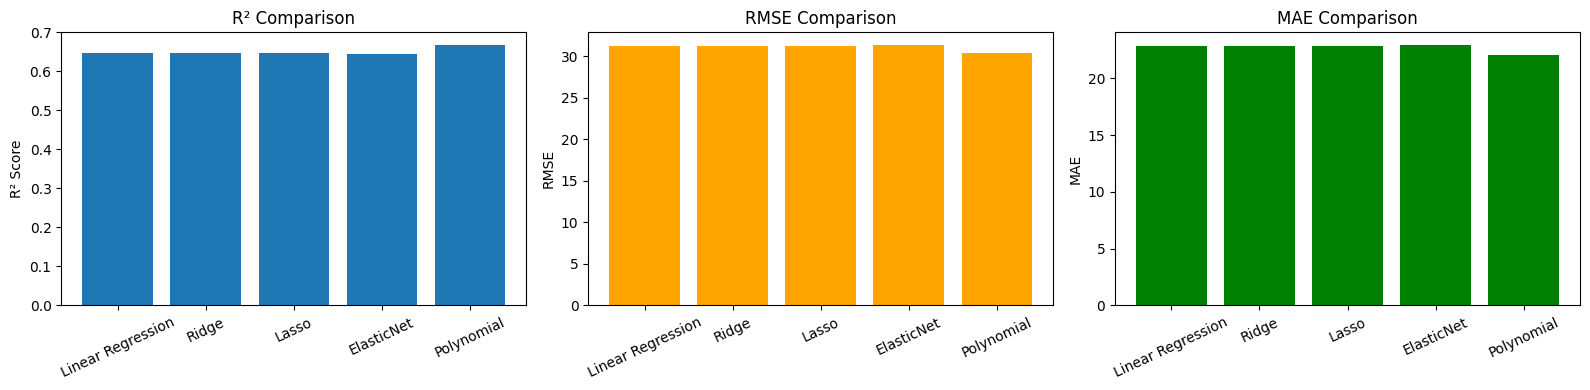

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(results["Algorithm"], results["R2"])
axes[0].set_ylabel("R\u00b2 Score")
axes[0].set_title("R\u00b2 Comparison")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(results["Algorithm"], results["RMSE"], color="orange")
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE Comparison")
axes[1].tick_params(axis="x", rotation=25)

axes[2].bar(results["Algorithm"], results["MAE"], color="green")
axes[2].set_ylabel("MAE")
axes[2].set_title("MAE Comparison")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

Best model: Polynomial


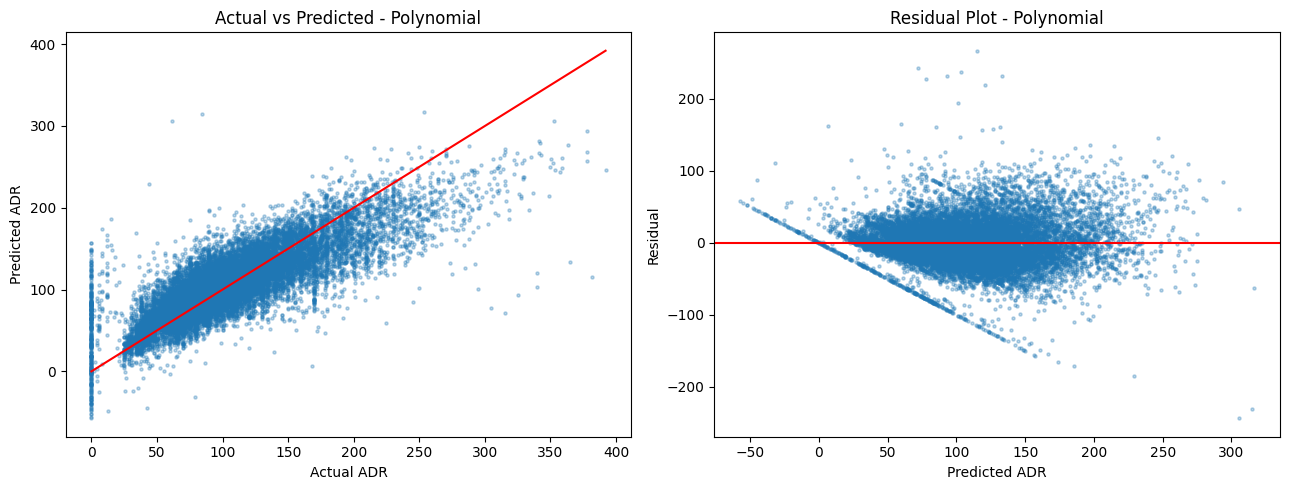

In [ ]:
# Actual vs Predicted and residuals for the best model
best_name = results.loc[results["R2"].idxmax(), "Algorithm"]

best_pred = {
    "Linear Regression": lr_pred,
    "Ridge": ridge_pred,
    "Lasso": lasso_pred,
    "ElasticNet": enet_pred,
    "Polynomial": poly_pred
}[best_name]

print("Best model:", best_name)

residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, best_pred, s=5, alpha=0.3)

axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

axes[0].set_xlabel("Actual ADR")
axes[0].set_ylabel("Predicted ADR")
axes[0].set_title("Actual vs Predicted - " + best_name)

axes[1].scatter(best_pred, residuals, s=5, alpha=0.3)
axes[1].axhline(0, color="red")
axes[1].set_xlabel("Predicted ADR")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual Plot - " + best_name)

plt.tight_layout()
plt.show()